<h1 style="text-align:center;">Comparative Evaluation of Machine Learning Models for Credit Default Prediction</h1>

<p style="text-align:left; font-size:18px;">
<b>Name:</b> Aryan Vora <br>
<b>Programme:</b> MSc Applied Statistics <br>
<b>University:</b> Birkbeck, University of London <br>
<b>Academic Year:</b> 2025-2026 <br>
<b>Word Count:</b> 3000
</p>

<h2 style="margin-top:30px;">1. Introduction</h2>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Credit risk modelling plays a crucial role in the financial industry, particularly for banks and lending institutions that aim to minimise potential losses arising from customer defaults. Accurately identifying high risk borrowers allows institutions to make informed lending decisions, optimise portfolio performance, and comply with regulatory requirements.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
In recent years, the increasing availability of large-scale financial datasets and advancements in computational techniques have led to the widespread adoption of machine learning methods in credit risk analysis. Traditional statistical approaches, such as logistic regression, continue to be widely used due to their interpretability and simplicity. However, more advanced techniques, including ensemble methods and neural networks, have been introduced to capture complex, non-linear relationships within the data.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The primary objective of this project is to develop and compare multiple machine learning models for predicting credit default. Specifically, this study evaluates the performance of logistic regression, random forest, and artificial neural networks using a real world credit dataset. The models are assessed based on key performance metrics such as accuracy, precision, recall, and ROC-AUC, with particular emphasis on the ability to correctly identify defaulters.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
This analysis is conducted from the perspective of a financial practitioner, where the cost of misclassification is asymmetric. In particular, failing to identify a defaulter (false negative) can lead to significant financial losses, making recall an important metric in model evaluation. Therefore, this study not only compares predictive performance but also examines the practical implications of each model in a credit risk context.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The findings of this project aim to provide insights into the trade-offs between model complexity, interpretability, and predictive performance, thereby supporting more effective decision making in credit risk management.
</p>

<h2 style="margin-top:30px;">2. Background</h2>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Credit risk modelling is a fundamental component of modern financial systems, used by banks and lending institutions to assess the likelihood that a borrower will default on their financial obligations. Traditional credit scoring techniques have largely relied on statistical models, particularly logistic regression, due to their interpretability and ease of implementation. Logistic regression estimates the probability of default by modelling the relationship between a binary response variable and a set of explanatory variables, making it suitable for classification problems in finance.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
However, financial data often exhibit complex, non-linear relationships that cannot be fully captured by linear models. This limitation has led to the adoption of machine learning techniques, which offer greater flexibility in modelling interactions and non-linear patterns. Among these, ensemble methods such as Random Forest have gained popularity due to their ability to improve predictive performance by combining multiple decision trees. Random Forest reduces overfitting and handles multicollinearity effectively, making it well suited for high dimensional financial datasets.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
This study builds on these concepts by applying and comparing logistic regression, Random Forest, and neural networks to a real world credit dataset, with the aim of evaluating their effectiveness in predicting default and their relevance in a financial practitioner setting.
</p>

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neural_network import MLPClassifier

# Display Settings
pd.set_option('display.max_columns', None)

<h2 style="margin-top:30px;">3. Data</h2>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The dataset used in this study is the “Default of Credit Card Clients” dataset obtained from the UCI Machine Learning Repository. The dataset contains information on 30,000 credit card clients and includes demographic, financial, and behavioural variables.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The response variable is a binary indicator of default payment, where 1 represents default and 0 represents non-default. The dataset includes 23 explanatory variables capturing different aspects of customer behaviour and financial status.
</p>

In [2]:
df = pd.read_csv("Data - Data.csv", header = 1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


<h3>3.1 Variable Description</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The explanatory variables can be grouped into four main categories:
</p>

<ul style="font-size:18px; line-height:1.6;">
<li><b>Credit Information:</b> LIMIT_BAL represents the total credit limit assigned to the customer.</li>
<li><b>Demographic Variables:</b> SEX, EDUCATION, MARRIAGE, and AGE provide personal information about the customer.</li>
<li><b>Repayment History:</b> PAY_0 to PAY_6 represent the customer’s repayment status over the past six months. These variables are ordinal, where -1 indicates timely payment and positive values indicate the number of months of payment delay.</li>
<li><b>Billing and Payment Behaviour:</b> BILL_AMT1 to BILL_AMT6 represent the monthly bill statements, while PAY_AMT1 to PAY_AMT6 represent the amounts paid by the customer over the same period.</li>
</ul>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The repayment history variables are particularly important, as they capture past financial behaviour, which is a strong indicator of future default risk.
</p>

In [4]:
# Basic Structure
df.shape

(30000, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [6]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [7]:
# Rename Target Variable
df.rename(columns={"default payment next month": "default"}, inplace=True)

In [8]:
# Check Missing Values
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [9]:
df.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [10]:
# Understand Categorical Variables
# Gender 
df['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

X2: Gender (1 = male; 2 = female)

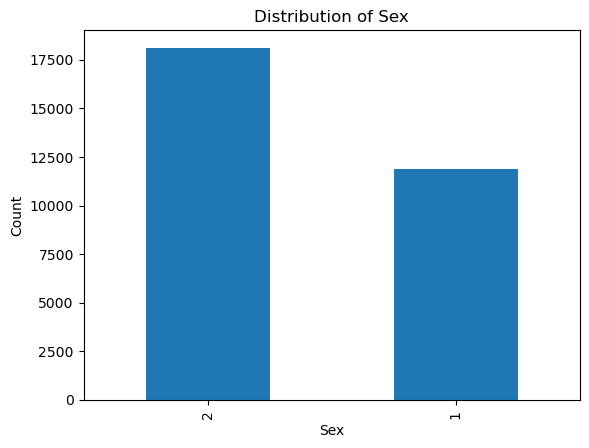

In [11]:
df["SEX"].value_counts().plot(kind='bar')
plt.title(f"Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [12]:
# Education 
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [13]:
# Handle Categorical Variables 
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others)

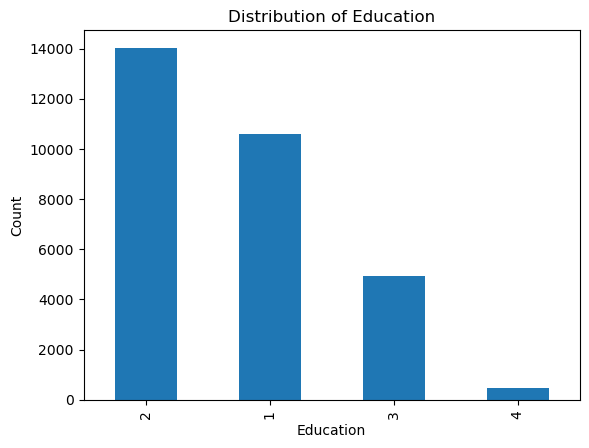

In [14]:
df["EDUCATION"].value_counts().plot(kind='bar')
plt.title(f"Distribution of Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

In [15]:
# Marriage 
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [16]:
# Handle Categorical Variables 
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

X4: Marital status (1 = married; 2 = single; 3 = others)

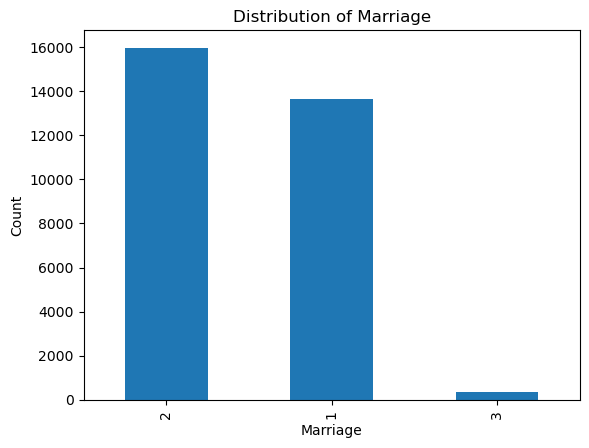

In [17]:
df["MARRIAGE"].value_counts().plot(kind='bar')
plt.title(f"Distribution of Marriage")
plt.xlabel("Marriage")
plt.ylabel("Count")
plt.show()

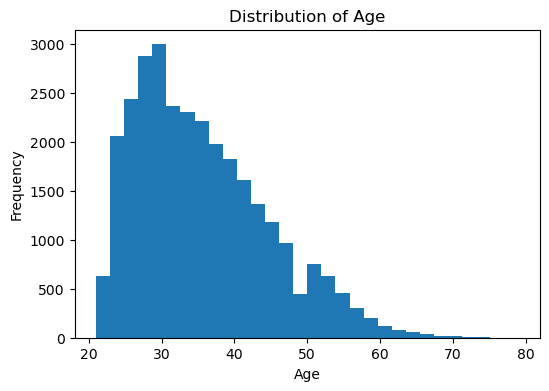

In [18]:
# Univariate Analysis
# Age 
plt.figure(figsize=(6,4))
plt.hist(df['AGE'], bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

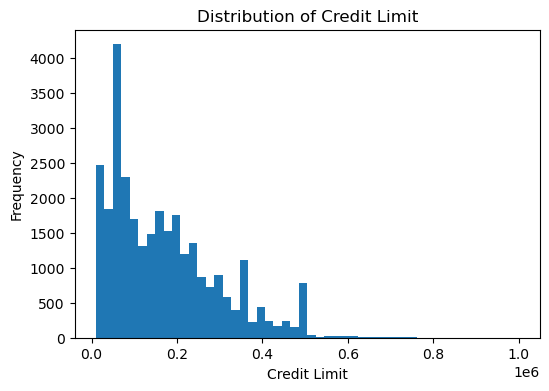

In [19]:
# Credit Limit
plt.figure(figsize=(6,4))
plt.hist(df['LIMIT_BAL'], bins=50)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

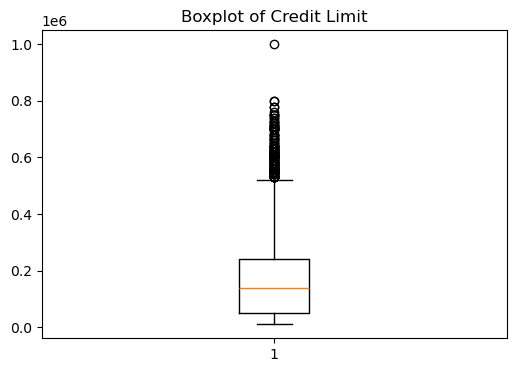

In [20]:
# Outlier Detection 
# Credit Limit 
plt.figure(figsize=(6,4))
plt.boxplot(df['LIMIT_BAL'])
plt.title("Boxplot of Credit Limit")
plt.show()

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The boxplot reveal the presence of outliers in credit limit, which is expected in financial datasets due to high-value customers.
</p>

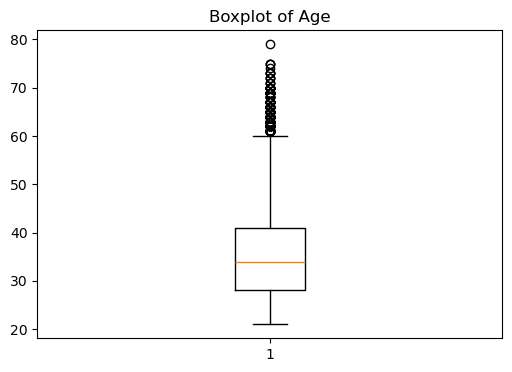

In [21]:
# Age 
plt.figure(figsize=(6,4))
plt.boxplot(df['AGE'])
plt.title("Boxplot of Age")
plt.show()

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The boxplot of age indicates that the majority of customers are between 28 and 40 years old, with a median around 34 years. While several observations above 60 years are identified as outliers. These values are realistic and reflect the presence of older customers in the dataset. Therefore, no outlier treatment was applied to the age variable.
</p>

In [22]:
# Skewness 
df[['LIMIT_BAL','AGE']].skew()

LIMIT_BAL    0.992867
AGE          0.732246
dtype: float64

In [23]:
# Correlation Analysis 
# Correlation Matrix
corr_matrix = df.corr()
corr_matrix

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
ID,1.000000,0.026179,0.018497,0.037659,-0.028208,0.018678,-0.030575,-0.011215,-0.018494,-0.002735,-0.022199,-0.020270,0.019389,0.017982,0.024354,0.040351,0.016705,0.016730,0.009742,0.008406,0.039151,0.007793,0.000652,0.003000,-0.013952
LIMIT_BAL,0.026179,1.000000,0.024755,-0.231088,-0.111012,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,-0.235195,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595,-0.153520
SEX,0.018497,0.024755,1.000000,0.013627,-0.028522,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,-0.044008,-0.033642,-0.031183,-0.024563,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766,-0.039961
EDUCATION,0.037659,-0.231088,0.013627,1.000000,-0.136797,0.182434,0.112593,0.129703,0.122425,0.116531,0.104088,0.088986,0.016597,0.011980,0.006714,-0.006131,-0.012439,-0.012646,-0.041088,-0.032793,-0.044293,-0.040949,-0.045138,-0.044061,0.033842
MARRIAGE,-0.028208,-0.111012,-0.028522,-0.136797,1.000000,-0.412001,0.018557,0.023620,0.032399,0.031831,0.034377,0.033168,-0.027832,-0.025294,-0.029082,-0.027274,-0.029270,-0.025066,-0.004653,-0.009513,-0.004250,-0.013970,-0.003019,-0.008383,-0.027575
AGE,0.018678,0.144713,-0.090874,0.182434,-0.412001,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,-0.048773,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478,0.013890
PAY_0,-0.030575,-0.271214,-0.057643,0.112593,0.018557,-0.039447,1.000000,0.672164,0.574245,0.538841,0.509426,0.474553,0.187068,0.189859,0.179785,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673,0.324794
PAY_2,-0.011215,-0.296382,-0.070771,0.129703,0.023620,-0.050148,0.672164,1.000000,0.766552,0.662067,0.622780,0.575501,0.234887,0.235257,0.224146,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500,0.263551
PAY_3,-0.018494,-0.286123,-0.066096,0.122425,0.032399,-0.053048,0.574245,0.766552,1.000000,0.777359,0.686775,0.632684,0.208473,0.237295,0.227494,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861,0.235253
PAY_4,-0.002735,-0.267460,-0.060173,0.116531,0.031831,-0.049722,0.538841,0.662067,0.777359,1.000000,0.819835,0.716449,0.202812,0.225816,0.244983,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565,0.216614


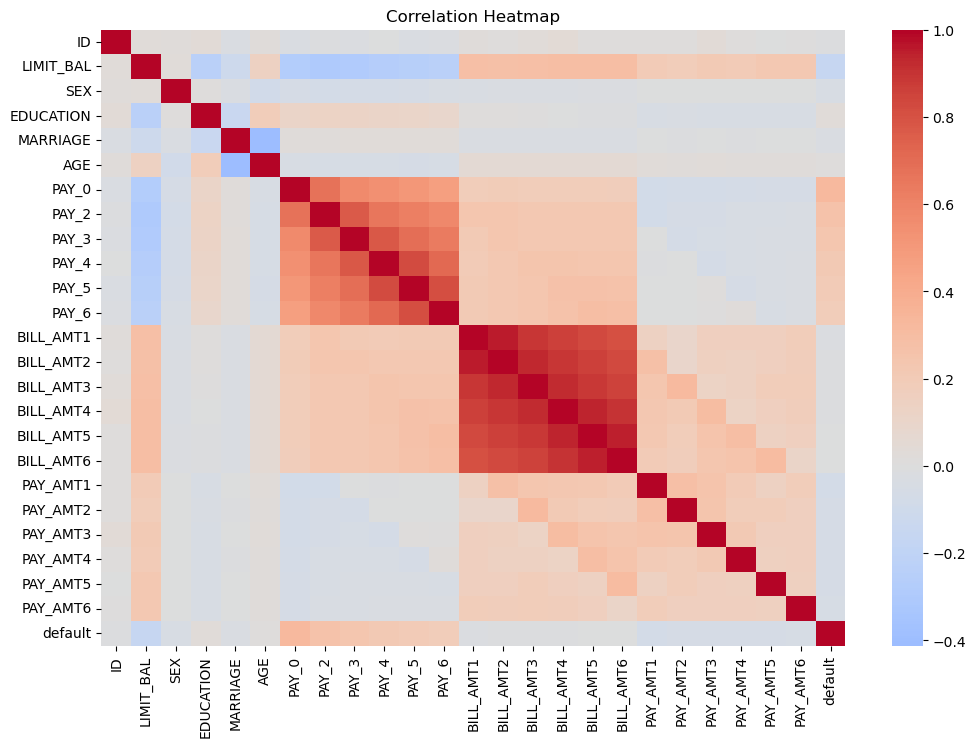

In [24]:
# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

/var/folders/wm/9x5zvmqj35q7jk6f_dx487vw0000gn/T/ipykernel_65007/3762106691.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['LIMIT_BAL'], 10))['default'].mean().plot()


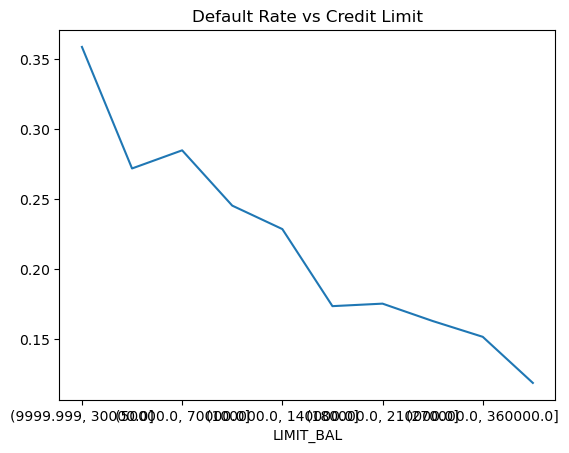

In [25]:
# Linearity
df.groupby(pd.qcut(df['LIMIT_BAL'], 10))['default'].mean().plot()
plt.title("Default Rate vs Credit Limit")
plt.show()

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The relationship between credit limit and default probability shows a clear decreasing trend, where higher credit limits are associated with lower default rates. This suggests that credit limit is a strong predictor of default risk. The observed pattern appears approximately monotonic, supporting the assumption of linearity in the log-odds for this variable.
</p>

In [26]:
# Feature Selection 
df.drop(columns=['ID'], inplace=True)

In [27]:
# Splitting Dataset
X = df.drop('default', axis=1)
y = df['default']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 
# Stratify is important due to class imbalance

In [29]:
# Encoding Categorical Variables
X_train = pd.get_dummies(X_train, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [30]:
# Feature Scaling 
col = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_2',
       'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']
num_cols = ['LIMIT_BAL','AGE'] + [col for col in X_train.columns if 'BILL_AMT' in col or 'PAY_AMT' in col]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

<h3>3.2 Data Quality and Preprocessing</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Initial data exploration showed that the dataset does not contain missing values, ensuring completeness of the observations. The ID variable was removed as it does not contribute to predictive modelling. Categorical variables such as gender, education, and marital status were encoded appropriately for model implementation.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Certain variables, particularly billing amounts and payment amounts, exhibited large differences in scale and skewed distributions. These variables were standardised using feature scaling techniques to improve model performance, especially for logistic regression and neural networks. The repayment status variables, although ordinal, were treated as numerical features to preserve the ordering information.
</p>

<h3>3.3 Exploratory Data Analysis</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Exploratory analysis revealed that the dataset is moderately imbalanced, with a significantly higher proportion of non-default cases compared to default cases. This imbalance highlights the importance of using evaluation metrics beyond accuracy.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The distribution of credit limits is right-skewed, indicating that most customers have relatively lower credit limits, with a small number of high value clients. Age distribution shows that the majority of customers fall within the working age population.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Correlation analysis indicates strong relationships among billing and payment variables, suggesting the presence of multicollinearity. Additionally, repayment history variables show a noticeable association with default behaviour, confirming their importance in predictive modelling.
</p>

<h3>3.4 Data Splitting</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The dataset was split into training and testing sets using a 70:30 ratio, with stratification applied to preserve the class distribution of the target variable. This ensures that model evaluation is performed on unseen data while maintaining representativeness of the dataset.
</p>

<h2 style="margin-top:30px;">4. Methodology</h2>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
This study adopts a comparative modelling approach to evaluate the performance of different machine learning techniques in predicting credit default. Three models were implemented: Logistic Regression, Random Forest, and Artificial Neural Networks. These models were selected to represent increasing levels of complexity, allowing for a comprehensive comparison between traditional statistical methods and modern machine learning approaches.
</p>

<h3>4.1 Modelling Framework</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The modelling process follows a structured pipeline. The dataset was first split into training and testing sets using a 70:30 ratio with stratification to preserve class distribution. Categorical variables were encoded, and feature scaling was applied where required. Logistic regression and neural network models were trained on scaled data, while Random Forest was trained on unscaled data due to its tree-based structure.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Model performance was evaluated using multiple metrics, including accuracy, precision, recall, and the area under the ROC curve (ROC-AUC). Given the imbalanced nature of the dataset, particular emphasis was placed on recall for the default class and ROC-AUC, as these metrics provide a more meaningful assessment of model performance in credit risk applications.
</p>

<h3>4.2 Logistic Regression</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Logistic regression was used as the baseline model due to its widespread application in credit risk modelling and its interpretability. The model estimates the probability of default by modelling the log-odds of the response variable as a linear function of the predictors. To address class imbalance, class weights were incorporated to ensure that default cases were appropriately penalised during model training.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;"> 
<li style="font-size:18px; text-align:justify; line-height:1.6;">Assumptions of Logistic Regression:-</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">1. Binary Dependent Variable</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">2. Independence of Observations</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">3. No Strong Multicollinearity</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">4. Linearity in the Log-odds</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">5. No Extreme Outliers</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">6. Large Sample Size</li>
</p>

In [31]:
# Fitting Logistic Regression Model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
# Predictions 
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [33]:
# Accuracy 
accuracy_score(y_test, y_pred)

0.6827777777777778

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The logistic regression model achieved an accuracy of approximately 68%. However, given the class imbalance in the dataset, accuracy alone is not an appropriate performance metric. Therefore, additional evaluation metrics such as precision, recall, and ROC-AUC were considered for a more comprehensive assessment.
</p>

In [34]:
# Confusion Matrix 
confusion_matrix(y_test, y_pred)

array([[4875, 2134],
       [ 721, 1270]])

<p style="font-size:18px; text-align:justify; line-height:1.6;"> 
The confusion matrix shows that the model correctly identified a substantial number of non-defaulters (4875) and defaulters (1270). However, it also produced a significant number of false positives (2134), indicating that many non-defaulters were incorrectly classified as high risk.
</p>

In [35]:
# Classification Report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.70      0.77      7009
           1       0.37      0.64      0.47      1991

    accuracy                           0.68      9000
   macro avg       0.62      0.67      0.62      9000
weighted avg       0.76      0.68      0.71      9000



<p style="font-size:18px; text-align:justify; line-height:1.6;"> 
The classification report indicates that the model performs well in identifying non-defaulters, with a precision of 87% and recall of 70%. For defaulters, the model achieves a recall of approximately 64%, suggesting a reasonable ability to detect risky customers. However, the precision for defaulters is relatively low (37%), indicating a high number of false positives. This reflects a trade-off between identifying risky customers and incorrectly classifying safe customers as high risk.
</p>

In [36]:
# ROC-AUC
roc_auc_score(y_test, y_prob)

np.float64(0.7172911931627837)

<p style="font-size:18px; text-align:justify; line-height:1.6;"> 
The logistic regression model achieved a ROC-AUC score of approximately 0.72, indicating a good ability to distinguish between defaulters and non-defaulters. This suggests that, despite moderate accuracy, the model has meaningful predictive power and is effective in ranking customers by risk.The logistic regression model achieved a ROC-AUC score of approximately 0.72, indicating a good ability to distinguish between defaulters and non-defaulters. This suggests that, despite moderate accuracy, the model has meaningful predictive power and is effective in ranking customers by risk.
</p>

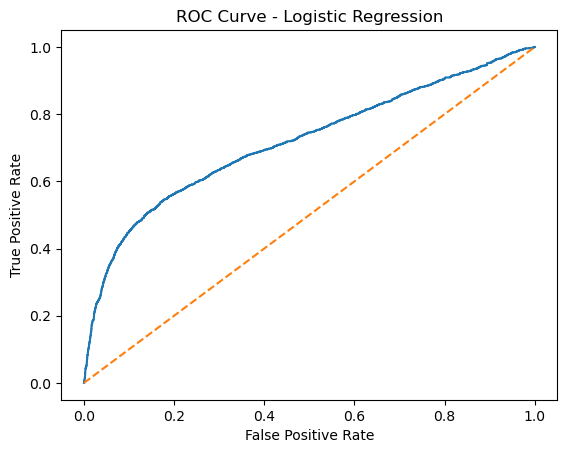

In [37]:
# ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

<p style="font-size:18px; text-align:justify; line-height:1.6;"> 
The ROC curve lies significantly above the diagonal baseline, indicating that the model performs better than random classification. The curve demonstrates a reasonable trade-off between true positive rate and false positive rate, consistent with the ROC-AUC value of approximately 0.72. This suggests that the model has a good ability to distinguish between defaulters and non-defaulters, although there is room for improvement.The ROC curve lies significantly above the diagonal baseline, indicating that the model performs better than random classification. The curve demonstrates a reasonable trade-off between true positive rate and false positive rate, consistent with the ROC-AUC value of approximately 0.72. This suggests that the model has a good ability to distinguish between defaulters and non-defaulters, although there is room for improvement.
</p>

<h3>4.3 Random Forest</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Random Forest is an ensemble learning method that constructs multiple decision trees and aggregates their predictions. It is particularly effective in capturing non-linear relationships and interactions between variables. Unlike logistic regression, Random Forest does not require feature scaling and is robust to multicollinearity.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
<li style="font-size:18px; text-align:justify; line-height:1.6;">Assumptions of Random Forest:-</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">1. Independent Observations</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">2. Sufficient Data</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">3. Handles Multicollinearity</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">4. Can Capture Non Linearity</li>
</p>




In [38]:
df = pd.read_csv("Data - Data.csv", header = 1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [39]:
# Rename Target Variable
df.rename(columns={"default payment next month": "default"}, inplace=True)

In [40]:
# Handle Categorical Variables 
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [41]:
# Handle Categorical Variables 
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

In [42]:
# Feature Selection 
df.drop(columns=['ID'], inplace=True)

In [43]:
# Splitting Dataset
X = df.drop('default', axis=1)
y = df['default']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 
# Stratify is important due to class imbalance

In [45]:
# Encoding Categorical Variables
X_train = pd.get_dummies(X_train, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [46]:
# Fit Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [47]:
# Predictions 
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [48]:
# Accuracy 
accuracy_score(y_test, y_pred_rf)

0.8126666666666666

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The Random Forest model achieved a higher accuracy of approximately 81%, outperforming logistic regression. However, due to class imbalance, accuracy is not a reliable performance metric.
</p>

In [49]:
# Confusion Matrix 
confusion_matrix(y_test, y_pred_rf)

array([[6638,  371],
       [1315,  676]])

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The Random Forest model demonstrates strong performance in identifying non-defaulters, with a low number of false positives. However, it exhibits a significantly lower recall for defaulters compared to logistic regression, indicating that many risky customers are not identified. This highlights a trade-off between precision and recall, where Random Forest is more conservative but less effective in detecting default risk.
</p>

In [50]:
# Classification Report 
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      7009
           1       0.65      0.34      0.45      1991

    accuracy                           0.81      9000
   macro avg       0.74      0.64      0.67      9000
weighted avg       0.79      0.81      0.79      9000



<p style="font-size:18px; text-align:justify; line-height:1.6;">
The Random Forest model achieved a higher overall accuracy (81%) compared to logistic regression. It also demonstrated improved precision in identifying defaulters. However, its recall for defaulters was significantly lower (34%), indicating that a large proportion of risky customers were not detected. This highlights a trade-off between precision and recall, where Random Forest is more conservative but less effective for risk identification.
</p>

In [51]:
# ROC-AUC
roc_auc_score(y_test, y_prob_rf)

np.float64(0.7558104063520541)

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The Random Forest model achieved a ROC-AUC score of approximately 0.76, outperforming the logistic regression model (AUC ≈ 0.72). This indicates that Random Forest has a stronger ability to distinguish between defaulters and non-defaulters.
</p>

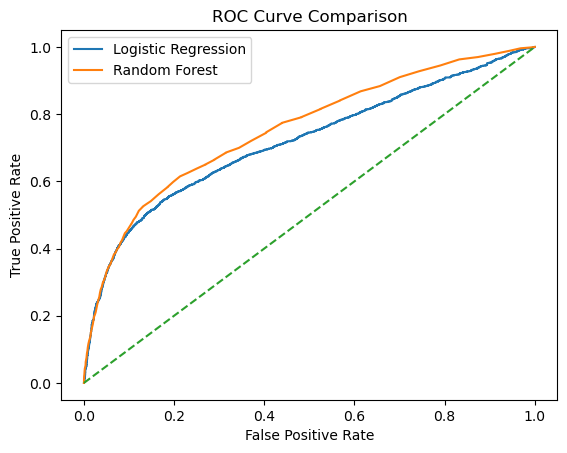

In [52]:
# ROC Curve 
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The ROC curve comparison shows that the Random Forest model consistently outperforms logistic regression across all classification thresholds. The curve for Random Forest lies above that of logistic regression, indicating superior discriminatory power. This is consistent with the higher ROC-AUC value achieved by Random Forest (≈0.76) compared to logistic regression (≈0.72).
</p>

<h3>4.4 Artifical Neural Network</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
An artificial neural network model was implemented using a multilayer perceptron architecture. The model consisted of two hidden layers with non-linear activation functions, allowing it to capture complex relationships in the data. Feature scaling was essential for this model to ensure efficient training and convergence.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
<li style="font-size:18px; text-align:justify; line-height:1.6;">Assumptions for Artificial Neural Network:-</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">1. Independent Observations</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">2. Sufficient Data</li>
<li style="font-size:18px; text-align:justify; line-height:1.6;">3. No Severe Imbalance Issues</li> 
</p>


In [53]:
df = pd.read_csv("Data - Data.csv", header = 1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [54]:
# Rename Target Variable
df.rename(columns={"default payment next month": "default"}, inplace=True)

In [55]:
# Handle Categorical Variables 
df['EDUCATION'] = df['EDUCATION'].replace([0,5,6], 4)
df['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

In [56]:
# Handle Categorical Variables 
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

In [57]:
# Feature Selection 
df.drop(columns=['ID'], inplace=True)

In [58]:
# Splitting Dataset
X = df.drop('default', axis=1)
y = df['default']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) 
# Stratify is important due to class imbalance

In [60]:
# Encoding Categorical Variables
X_train = pd.get_dummies(X_train, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['SEX','EDUCATION','MARRIAGE'], drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [61]:
# Feature Scaling 
col = ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_2', 'EDUCATION_2',
       'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3']
num_cols = ['LIMIT_BAL','AGE'] + [col for col in X_train.columns if 'BILL_AMT' in col or 'PAY_AMT' in col]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [62]:
# Fitting Aritifical Netural Network 
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)
nn_model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42)

In [63]:
# Predictions 
y_pred_nn = nn_model.predict(X_test)
y_prob_nn = nn_model.predict_proba(X_test)[:, 1]

In [64]:
# Accuracy
accuracy_score(y_test, y_pred_nn)

0.7904444444444444

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The neural network model achieved an accuracy of approximately 79%, outperforming logistic regression but slightly underperforming compared to the Random Forest model.
</p>

In [65]:
# Confusion Matrix 
confusion_matrix(y_test, y_pred_nn)

array([[6417,  592],
       [1294,  697]])

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The neural network model demonstrates a balanced trade-off between precision and recall. However, similar to the Random Forest model, it exhibits relatively low recall for defaulters, indicating that a significant number of risky customers are not identified. While its performance is more balanced than Random Forest, it does not outperform logistic regression in detecting default risk.
</p>

In [66]:
# Classification Report 
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      7009
           1       0.54      0.35      0.42      1991

    accuracy                           0.79      9000
   macro avg       0.69      0.63      0.65      9000
weighted avg       0.77      0.79      0.77      9000



<p style="font-size:18px; text-align:justify; line-height:1.6;">
The neural network model demonstrates strong performance in identifying non-defaulters, with high recall for the majority class. However, similar to the Random Forest model, it exhibits relatively low recall for defaulters (approximately 35%), indicating that many risky customers are not identified. Although it achieves a balance between precision and recall, it does not significantly outperform the other models.
</p>

In [67]:
# ROC-AUC
roc_auc_score(y_test, y_prob_nn)

np.float64(0.7314521495968553)

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The neural network model achieved a ROC-AUC score of approximately 0.73, indicating a good ability to distinguish between defaulters and non-defaulters. While this represents a slight improvement over logistic regression, it remains lower than the performance of the Random Forest model (AUC ≈ 0.76).
</p>

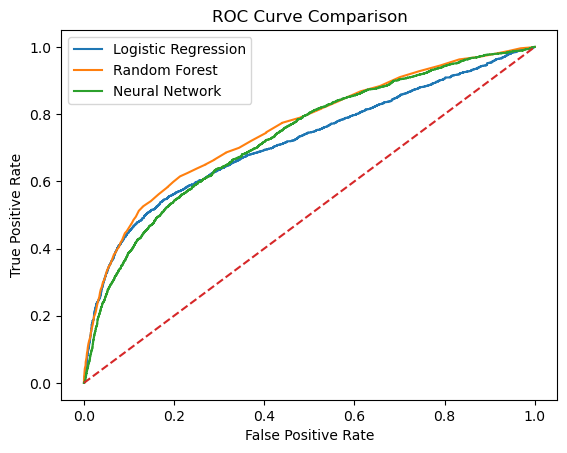

In [68]:
# Roc Curve 
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_nn, tpr_nn, label="Neural Network")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The neural network performs slightly better than logistic regression, its performance remains close to that of Random Forest without providing a significant improvement.
</p>

<h3>5. Results </h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The analysis shows that model choice depends on the trade-off between recall (catching defaulters) and precision (avoiding false alarms).
</p>

<ul style="font-size:18px; line-height:1.6;">
<li>If the objective is to minimise risk (e.g. real-world banking), the Logistic Regression model is preferred.</li>
<li>If the objective is to strengthen overall predictive power, the Random Forest model is preferred.</li>
</ul>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
This study compared logistic regression, Random Forest, and neural network models for credit default prediction. The Random Forest model achieved the highest ROC-AUC, indicating superior ability to distinguish between defaulters and non-defaulters. However, it exhibited low recall for the default class, meaning that many risky customers were not identified. Logistic regression, while less accurate overall, demonstrated significantly higher recall and was more effective in identifying defaulters. The neural network did not significantly outperform the other models despite increased complexity.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
From a practical credit risk perspective, where the cost of missed defaults is high, logistic regression may be preferred. However, Random Forest offers strong predictive power and could be further improved through threshold tuning.
</p>

<h2 style="margin-top:30px;">6. Conclusion</h2>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
This study aimed to evaluate and compare the performance of three machine learning models: Logistic Regression, Random Forest, and Neural Networks, for predicting credit default. The analysis demonstrates that model performance depends on the trade-off between recall and precision, which is particularly important in credit risk applications.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
The Random Forest model achieved the highest accuracy and ROC-AUC, indicating superior overall predictive performance and strong ability to distinguish between defaulters and non-defaulters. However, it exhibited low recall for the default class, meaning that a significant number of risky customers were not identified. This limitation is critical in a financial context where missed defaults can result in substantial losses.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
In contrast, Logistic Regression demonstrated significantly higher recall, making it more effective in identifying defaulters. Although it produced a higher number of false positives, it aligns more closely with the objectives of risk minimisation in real world banking applications. The Neural Network model provided a balance between precision and recall but did not significantly outperform the other models despite increased complexity.
</p>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Overall, the findings suggest that Logistic Regression may be preferred when the primary objective is to minimise financial risk, while Random Forest may be more suitable when overall predictive performance is prioritised. These results highlight the importance of aligning model selection with business objectives rather than relying solely on accuracy or ROC-AUC.
</p>

<h3>6.1 Limitations</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
This study has several limitations. First, the dataset exhibits class imbalance, which may influence model performance, particularly in detecting defaulters. Second, the neural network model was not extensively tuned, which may limit its performance. Additionally, feature engineering was limited, and more sophisticated transformations could improve predictive accuracy.
</p>

<h3>6.2 Future Work</h3>

<p style="font-size:18px; text-align:justify; line-height:1.6;">
Future research could focus on improving model performance through techniques such as threshold tuning, resampling methods (e.g. SMOTE), and hyperparameter optimisation. Incorporating additional features or external data sources may also enhance predictive power. Furthermore, model interpretability techniques could be explored to better understand the drivers of default risk, which is particularly important in regulated financial environments.
</p>

<h2 style="margin-top:30px;">7. References</h2>

<ol style="font-size:18px; line-height:1.8;">

<li>
Yeh, I. (2009). <i>Default of Credit Card Clients [Dataset]</i>. UCI Machine Learning Repository. 
<a href="https://doi.org/10.24432/C55S3H" target="_blank">
https://doi.org/10.24432/C55S3H
</a>
</li>

<li>
Yeh, I., &amp; Lien, C. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. 
<i>Expert Systems with Applications</i>, 36, 2473–2480.
</li>

<li>
GeeksforGeeks. (2017, May 9). <i>Logistic Regression in Machine Learning</i>. 
<a href="https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/" target="_blank">
https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/
</a>
</li>

<li>
GeeksforGeeks. (2024, February 22). <i>Random Forest Algorithm in Machine Learning</i>. 
<a href="https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/" target="_blank">
https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/
</a>
</li>

<li>
GeeksforGeeks. (2020, June 24). <i>Artificial Neural Networks and its Applications</i>. 
<a href="https://www.geeksforgeeks.org/deep-learning/artificial-neural-networks-and-its-applications/" target="_blank">
https://www.geeksforgeeks.org/deep-learning/artificial-neural-networks-and-its-applications/
</a>
</li>

</ol>